# Clasificación de música por género

## 1. Propósito

El propósito de este examen es evaluar el cumplimiento de los objetivos de aprendizaje planteados al comienzo del curso:
- Identificar problemas que se pueden resolver usando Machine Learning supervisado.
- Implementar una solución de Machine Learning supervisado a problemas prácticos.
- Evaluar el desempeño de modelos de Machine Learning supervisado

## 2. Descripción del Problema

Considere el problema de clasificación de música por género en el conjunto de datos adjunto. En este examen se debe encontrar un clasificador para las siguientes clases:

- (1)   Dance and electronic.
- (2)   Jazz and blues.
- (3)   Soul and reggae.
- (4)   Punk.
- (5)   Metal.

Ignore los datos correspondientes a los demás géneros. Elimine del conjunto de datos el identificador de la canción, el título de la canción y el artista. El clasificador debe encontrar la clase a partir de las características restantes extraídas del audio de la canción.

## 3. Dataset y preparación de los datos

Utilice el conjunto de datos proporcionado para desarrollar el problema de clasificación. Realice el preprocesamiento que considere adecuado de acuerdo con las características de los datos.

Divida el conjunto de datos resultante en conjuntos de entrenamiento, validación y prueba. La partición y cualquier transformación aplicada a los datos deben justificarse apropiadamente.

Usted es libre de emplear cualquier tipo de modelo de Machine Learning supervisado, así como los métodos de selección de modelo y/o regularización que considere adecuados. Debe presentar evidencia del proceso de entrenamiento y selección realizado.

## 4. Evaluación

La evaluación del examen final se basará en los siguientes criterios:

- (10%) Adecuación y preprocesamiento de los datos.
- (10%) Evidencia del entrenamiento apropiado de sus modelos.
- (20%) Selección del tipo de modelo y método de selección de modelo y/o regularización utilizados, incluyendo evidencia numérica.
- (20%) Calidad de su modelo final. Se debe especificar y justificar claramente el criterio de desempeño utilizado. ¿Cuál es el desempeño esperado de su modelo en datos futuros? Dé evidencia numérica.
- (20%) Análisis de sus resultados.
- (20%) Calidad y orden del informe.

## 5. Entregables

El entregable es un informe (Jupyter notebook) del procedimiento llevado a cabo para llegar a su modelo final.

Este informe debe estar bien estructurado e incluir la información requerida en la evaluación. Incluya gráficas y tablas que le permitan presentar la información de manera concisa y clara. El código debe estar bien estructurado y apropiadamente comentado. En el notebook deben visualizarse las ejecuciones realizadas.

In [1]:
%pip install -q --upgrade pandas matplotlib scikit-learn tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


## Importamos las librerías

Estas son las librerías que utilizaremos para el desarrollo del proyecto.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Definimos constantes

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

DATA_PATH = Path("data/genre_dataset.txt")

STATE = 42

## Cargamos los datos

In [4]:
raw_data = pd.read_csv(
    DATA_PATH,
    skiprows=9 # skip comments
)

# Remove '%' from column names
raw_data.columns = raw_data.columns.str.strip().str.lstrip('%').str.strip()

raw_data

,genre,track_id,artist_name,title,loudness,tempo,time_signature,key,mode,duration,avg_timbre1,avg_timbre2,avg_timbre3,avg_timbre4,avg_timbre5,avg_timbre6,avg_timbre7,avg_timbre8,avg_timbre9,avg_timbre10,avg_timbre11,avg_timbre12,var_timbre1,var_timbre2,var_timbre3,var_timbre4,var_timbre5,var_timbre6,var_timbre7,var_timbre8,var_timbre9,var_timbre10,var_timbre11,var_timbre12
0,classic pop and rock,TRFCOOU128F427AEC0,Blue Oyster Cult,Mes Dames Sarat,-8.697,155.007,1,9,1,246.33424,46.673067,14.613684,14.664215,0.176561,-9.346377,-12.341699,11.183382,7.405288,9.313765,3.201169,-0.152734,5.809709,14.930820,802.205948,1255.514569,580.030472,598.485223,575.337671,322.068603,321.726029,232.700609,186.805303,181.938688,151.508011
1,classic pop and rock,TRNJTPB128F427AE9F,Blue Oyster Cult,Screams,-10.659,148.462,1,4,0,189.80526,43.645377,-87.337150,41.051582,7.814770,-12.989848,-14.253599,6.126045,-2.448662,22.691713,-2.872706,1.427725,-6.710730,22.704843,1561.307072,2007.653070,1043.474073,585.694981,564.013736,510.177022,400.200186,365.119588,238.099708,197.933757,251.577525
2,classic pop and rock,TRLFJHA128F427AEEA,Blue Oyster Cult,Dance The Night Away,-13.494,112.909,1,10,0,158.19710,37.573538,-61.202030,28.760533,-13.788123,10.062347,-4.872030,-14.090243,5.580175,15.414011,4.556137,-1.877363,20.879475,58.459621,4644.001846,1204.856777,2736.520024,730.233239,665.203452,535.775111,439.335059,486.822970,265.333860,447.097987,251.880724
3,classic pop and rock,TRCQZAG128F427DB97,Blue Oyster Cult,Debbie Denise,-12.786,117.429,4,7,1,250.22649,42.566615,17.217897,53.484213,1.564362,-8.884632,-13.088890,-9.762620,1.373769,1.092876,1.479490,1.517015,8.562618,22.575460,691.140671,809.755802,563.908070,492.803819,378.382799,372.875044,231.941957,246.313305,168.400152,85.282462,339.897173
4,classic pop and rock,TRNXMNM128F427DB8C,Blue Oyster Cult,(Don't Fear) The Reaper,-14.093,141.536,4,9,0,307.06893,40.976507,-13.609779,39.566169,-5.602033,-17.754819,-21.833261,-5.600732,2.291770,3.526177,1.535449,2.763958,3.388757,34.294994,1062.180815,1093.684935,343.556047,889.163314,218.111796,304.862864,178.352161,440.478867,142.669283,81.061326,208.355152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59595,soul and reggae,TRGYRMA128E078FC55,Erykah Badu,Danger,-10.162,88.951,4,11,1,348.96934,40.231725,46.282408,-13.655822,5.946664,14.348422,-2.672532,5.951254,6.642360,6.464162,15.298649,-9.405466,2.804328,42.698623,3135.495359,4339.425990,4081.017023,1248.530483,1655.677367,1000.603204,650.139870,487.150838,503.846148,641.508417,395.121718
59596,soul and reggae,TRZZFQW128E078FC5A,Erykah Badu,Hollywood,-5.466,130.615,3,9,1,332.32934,43.813328,5.111750,-2.705070,-3.683494,2.478473,-3.406668,9.211850,3.222463,14.685264,3.570673,-7.111661,0.793817,52.380335,2852.962520,3759.486850,3703.892394,1413.063618,1375.104641,951.467238,621.927699,418.507034,409.707771,504.899788,350.913794
59597,soul and reggae,TRAMYBB128F424D86D,Erykah Badu,Think Twice,-9.494,88.976,4,3,1,182.04689,38.561170,21.603243,-43.954808,11.649718,-0.986997,-10.491520,-6.064987,-12.996223,8.259268,1.978779,1.043235,-2.172406,30.401080,2950.171909,4288.018243,3694.070826,1336.559501,1613.559675,1017.527699,1155.936991,422.885540,519.527734,538.895856,313.775934
59598,soul and reggae,TRABWFM128F424D86A,Erykah Badu / Dead Prez,The Grind,-7.617,67.929,3,0,1,169.42975,41.280131,8.233834,-41.325696,-1.864784,7.786002,0.071631,-14.726294,-6.791047,3.653238,11.307610,-5.241222,6.730477,32.521843,2362.093998,2846.537149,3655.514437,1811.926034,1705.581355,1024.020625,1052.533278,533.349475,591.853048,598.054091,443.893807


## Preparación del dataset

Buscamos en el set de datos valores nulos o duplicados para eliminarlos

In [5]:
print('Datos duplicados:', raw_data.duplicated().sum())
null_data = raw_data.isna().sum()
null_data = null_data[null_data > 0]
print('Datos nulos:', 'No hay valores nulos' if null_data.empty  else null_data)

Datos duplicados: 0
Datos nulos: No hay valores nulos


Como vemos en el análisis exploratorio, no se presentan datos duplicados ni valores nulos, por lo que no se hace necesario eliminar ni imputar nada.

Eliminamos las columnas que no nos interesan para el entrenamiento

In [6]:
data = raw_data.drop(columns=['track_id', 'artist_name', 'title'])
data

,genre,loudness,tempo,time_signature,key,mode,duration,avg_timbre1,avg_timbre2,avg_timbre3,avg_timbre4,avg_timbre5,avg_timbre6,avg_timbre7,avg_timbre8,avg_timbre9,avg_timbre10,avg_timbre11,avg_timbre12,var_timbre1,var_timbre2,var_timbre3,var_timbre4,var_timbre5,var_timbre6,var_timbre7,var_timbre8,var_timbre9,var_timbre10,var_timbre11,var_timbre12
0,classic pop and rock,-8.697,155.007,1,9,1,246.33424,46.673067,14.613684,14.664215,0.176561,-9.346377,-12.341699,11.183382,7.405288,9.313765,3.201169,-0.152734,5.809709,14.930820,802.205948,1255.514569,580.030472,598.485223,575.337671,322.068603,321.726029,232.700609,186.805303,181.938688,151.508011
1,classic pop and rock,-10.659,148.462,1,4,0,189.80526,43.645377,-87.337150,41.051582,7.814770,-12.989848,-14.253599,6.126045,-2.448662,22.691713,-2.872706,1.427725,-6.710730,22.704843,1561.307072,2007.653070,1043.474073,585.694981,564.013736,510.177022,400.200186,365.119588,238.099708,197.933757,251.577525
2,classic pop and rock,-13.494,112.909,1,10,0,158.19710,37.573538,-61.202030,28.760533,-13.788123,10.062347,-4.872030,-14.090243,5.580175,15.414011,4.556137,-1.877363,20.879475,58.459621,4644.001846,1204.856777,2736.520024,730.233239,665.203452,535.775111,439.335059,486.822970,265.333860,447.097987,251.880724
3,classic pop and rock,-12.786,117.429,4,7,1,250.22649,42.566615,17.217897,53.484213,1.564362,-8.884632,-13.088890,-9.762620,1.373769,1.092876,1.479490,1.517015,8.562618,22.575460,691.140671,809.755802,563.908070,492.803819,378.382799,372.875044,231.941957,246.313305,168.400152,85.282462,339.897173
4,classic pop and rock,-14.093,141.536,4,9,0,307.06893,40.976507,-13.609779,39.566169,-5.602033,-17.754819,-21.833261,-5.600732,2.291770,3.526177,1.535449,2.763958,3.388757,34.294994,1062.180815,1093.684935,343.556047,889.163314,218.111796,304.862864,178.352161,440.478867,142.669283,81.061326,208.355152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59595,soul and reggae,-10.162,88.951,4,11,1,348.96934,40.231725,46.282408,-13.655822,5.946664,14.348422,-2.672532,5.951254,6.642360,6.464162,15.298649,-9.405466,2.804328,42.698623,3135.495359,4339.425990,4081.017023,1248.530483,1655.677367,1000.603204,650.139870,487.150838,503.846148,641.508417,395.121718
59596,soul and reggae,-5.466,130.615,3,9,1,332.32934,43.813328,5.111750,-2.705070,-3.683494,2.478473,-3.406668,9.211850,3.222463,14.685264,3.570673,-7.111661,0.793817,52.380335,2852.962520,3759.486850,3703.892394,1413.063618,1375.104641,951.467238,621.927699,418.507034,409.707771,504.899788,350.913794
59597,soul and reggae,-9.494,88.976,4,3,1,182.04689,38.561170,21.603243,-43.954808,11.649718,-0.986997,-10.491520,-6.064987,-12.996223,8.259268,1.978779,1.043235,-2.172406,30.401080,2950.171909,4288.018243,3694.070826,1336.559501,1613.559675,1017.527699,1155.936991,422.885540,519.527734,538.895856,313.775934
59598,soul and reggae,-7.617,67.929,3,0,1,169.42975,41.280131,8.233834,-41.325696,-1.864784,7.786002,0.071631,-14.726294,-6.791047,3.653238,11.307610,-5.241222,6.730477,32.521843,2362.093998,2846.537149,3655.514437,1811.926034,1705.581355,1024.020625,1052.533278,533.349475,591.853048,598.054091,443.893807


Obtenemos los posibles valores de `genre`

In [7]:
data['genre'] = data['genre'].str.strip().str.replace(' ', '_')
data['genre'].value_counts()

genre
classic_pop_and_rock     23895
folk                     13192
dance_and_electronica     4935
jazz_and_blues            4334
soul_and_reggae           4016
punk                      3200
metal                     2103
classical                 1874
pop                       1617
hip-hop                    434
Name: count, dtype: int64

Sólo nos interesan las clases:

| Nombre | Clase en el conjunto de datos |
| ------ | ----------------------------- |
| Dance and electronic | dance_and_electronica |
| Jazz and blues | jazz_and_blues |
| Soul and reggae | soul_and_reggae |
| Punk | punk |
| Metal | metal |

In [8]:
selected_genres = ['dance_and_electronica', 'jazz_and_blues', 'soul_and_reggae', 'punk', 'metal']

reduced_data = data[
    data['genre'].isin(selected_genres)
].copy()

print('Tamaño del dataset final, reducido a los géneros que nos interesan:\n', reduced_data.shape)
reduced_data['genre'].value_counts()

Tamaño del dataset final, reducido a los géneros que nos interesan:
 (18588, 31)


genre
dance_and_electronica    4935
jazz_and_blues           4334
soul_and_reggae          4016
punk                     3200
metal                    2103
Name: count, dtype: int64

Separamos los datos para las tareas de entrenamiento del modelo, vamos a separar en conjuntos de entrenamiento y test. Como vamos a utilizar un StratifiedKFold para búsqueda de hiperparámetros con GridSearchCV, el propio conjunto de entrenamiento durante el proceso va a ser dividido en conjuntos de validación.

In [9]:
X_raw = reduced_data.drop(columns=['genre'])
y_raw = reduced_data['genre']

X_raw.describe()

,loudness,tempo,time_signature,key,mode,duration,avg_timbre1,avg_timbre2,avg_timbre3,avg_timbre4,avg_timbre5,avg_timbre6,avg_timbre7,avg_timbre8,avg_timbre9,avg_timbre10,avg_timbre11,avg_timbre12,var_timbre1,var_timbre2,var_timbre3,var_timbre4,var_timbre5,var_timbre6,var_timbre7,var_timbre8,var_timbre9,var_timbre10,var_timbre11,var_timbre12
count,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000,18588.000000
mean,-10.744615,125.392746,3.590973,5.315472,0.621476,275.822458,41.913635,0.900085,1.132138,3.460564,-4.061123,-9.729690,-1.385574,-0.325474,3.242254,3.221818,-0.223115,2.297796,33.608265,2657.348946,2332.658352,1724.129930,967.193763,1003.513360,657.256527,553.354325,410.064842,343.244339,316.391822,312.080078
std,5.888380,37.779513,1.266568,3.631030,0.485032,150.007035,7.122675,59.231593,39.663455,18.962652,25.895930,13.724088,15.542524,8.865156,11.643265,6.637386,4.881789,8.630888,22.338158,2035.021000,1546.659598,1253.456244,531.593275,667.433298,363.948788,339.022347,237.880382,179.068434,208.065543,181.830873
min,-48.057000,0.000000,0.000000,0.000000,0.000000,1.201180,8.282830,-318.656281,-257.525596,-120.723153,-137.779000,-73.029843,-165.322686,-66.731355,-119.487529,-38.235825,-46.202360,-63.556803,0.810455,112.294714,95.505318,110.570448,99.207949,37.403374,60.896276,36.801235,33.611425,21.861296,20.006805,21.180689
25%,-13.505000,97.868500,3.000000,2.000000,0.000000,190.118730,37.888075,-29.152897,-21.807789,-7.730504,-20.765769,-19.463334,-10.303966,-5.116924,-3.217365,-1.048197,-2.947482,-2.736511,17.952351,1345.045257,1234.861967,882.238187,618.331374,523.179264,400.763205,321.884676,256.780750,214.455064,174.926873,195.388870
50%,-9.376000,122.996000,4.000000,5.000000,1.000000,247.170160,42.919508,10.581551,4.360082,1.131325,-3.297947,-11.171929,-1.363396,-0.199683,3.566729,3.451509,-0.190081,2.193536,29.249550,2176.070419,2072.293162,1435.779038,873.898431,858.882712,602.173646,476.455914,360.501429,308.876766,266.157676,280.335403
75%,-6.419750,148.078000,4.000000,9.000000,1.000000,330.324442,47.209024,40.953134,25.493438,12.471970,12.284154,-1.497215,7.839608,4.675313,10.297362,7.576872,2.618913,7.119675,43.405499,3385.459179,3025.224361,2194.404360,1186.228589,1301.098930,833.356107,692.912444,499.742202,432.616292,399.112359,379.170708
max,-0.052000,253.036000,7.000000,11.000000,1.000000,2873.808530,56.775537,448.373214,292.952706,130.195510,223.496056,100.846598,133.663628,60.334705,86.752806,38.294126,52.893625,60.741634,307.168640,47892.869990,20131.148234,17007.134106,16049.083490,8278.809040,5582.160728,4057.268420,3928.650500,1794.267857,4780.290858,2629.604610


Las escalas de los valores son muy amplias y distintas entre sí, por lo que conviene utilizar un escalador como StandardScaler o RobustScaler en el pre-procesamiento de los datos

## Slección del modelo

Para este ejercicio vamos a evaluar el rendimiento de los modelos de SVC, LogisticRegression y RandomForest, estos fueron seleccionados basados en las actividades del curso y en las siguientes referencias:

- [Do we Need Hundreds of Classifiers to Solve Real World Classification Problems?](https://www.jmlr.org/papers/volume15/delgado14a/delgado14a.pdf)
- [Why do tree-based models still outperform deep learning on tabular data?](https://arxiv.org/pdf/2207.08815)

### Separación del conjunto de train y test

Vamos a utilizar el 20% de los datos para test, el 80% restantes se utilizará para el entrenamiento. En lugar de crear una partición más para validación, se utilizará el método de validación cruzada, donde utilizaremos 5 folds. En cada iteración se utilizan 4 folds para entrenamiento y el restante es para validación.

En el método para separación de datos se especifica estratificación por la variable objetivo, para mantener aproximadamente la proporción de los 5 géneros en cada partición

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=STATE)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (14870, 30)
X_test shape: (3718, 30)


Métricas y estrategia KFold es común a todos los modelos

In [11]:
metrics = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=STATE)

### Logistic Regression

Definición del pipeline para LogisticRegression, para este tipo de modelo que es sensible a la escala de los datos por lo que vamos a utilizar escalado, evaluamos con StandardScaler y con RobustScaler en GridSearchCV

Para este modelo vamos a variar el parámetro `C` donde un valor pequeño indica una regularización más fuerte y un valor alto indica una regularización débil

In [12]:
# Model pipeline
model_lr = LogisticRegression(max_iter=2000, random_state=STATE)

steps_lr = [
    ('scaler', StandardScaler()),
    ('model', model_lr)
]

pipeline_lr = Pipeline(steps_lr)

# Model GridSearch
search_params_lr = {
    'scaler': [StandardScaler(), RobustScaler()],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}

search_lr = GridSearchCV(
    pipeline_lr,
    search_params_lr,
    scoring=metrics,
    refit='f1_macro',
    cv=kfold,
    n_jobs=-1
)

In [13]:
search_lr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'scaler': [StandardScaler(), RobustScaler()]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies 

In [14]:
print('Mejores parametros:')
print(search_lr.best_params_)

print('Mejor F1 macro:')
print(search_lr.best_score_)

Mejores parametros:
{'model__C': 100, 'model__class_weight': None, 'scaler': StandardScaler()}
Mejor F1 macro:
0.6676882997748418


### SVC

Ahora evaluamos SVC, para este tipo de modelo que es sensible a la escala de los datos por lo que vamos a utilizar escalado, evaluamos con StandardScaler y con RobustScaler en GridSearchCV.

Variamos `C` para variar el margen de clasificación, `gamma` para el alcance de las observaciones en RBF y el tema de `class_weight` con "balanced" para compensar diferencias entre las clases.

In [15]:
model_svc = SVC(cache_size=1000, random_state=STATE)

steps_svc = [
    ('scaler', StandardScaler()),
    ('model', model_svc)
]

pipeline_svc = Pipeline(steps_svc)

search_params_svc_linear = {
    'scaler': [StandardScaler(), RobustScaler()],
    'model__kernel': ['linear'],
    'model__C': [0.1, 1, 10],
    'model__class_weight': [None, 'balanced']
}

search_params_svc_rbf = {
    'scaler': [StandardScaler(), RobustScaler()],
    'model__kernel': ['rbf'],
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 0.01, 0.1],
    'model__class_weight': [None, 'balanced']
}

search_params_svc = [search_params_svc_linear, search_params_svc_rbf]

search_svc = GridSearchCV(
    pipeline_svc,
    search_params_svc,
    scoring=metrics,
    refit='f1_macro',
    cv=kfold,
    n_jobs=6,
    verbose=1
)

In [16]:
search_svc.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__kernel': ['linear'], 'scaler': [StandardScaler(), RobustScaler()]}, {'model__C': [0.1, 1, ...], 'model__class_weight': [None, 'balanced'], 'model__gamma': ['scale', 0.01, ...], 'model__kernel': ['rbf'], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters

In [17]:
print('Mejores parametros:')
print(search_svc.best_params_)

print('Mejor F1 macro:')
print(search_svc.best_score_)

Mejores parametros:
{'model__C': 1, 'model__class_weight': None, 'model__gamma': 0.1, 'model__kernel': 'rbf', 'scaler': RobustScaler()}
Mejor F1 macro:
0.7278401393206398


### Random Forest

Este tipo de modelo no necesita escalado de los datos. En este modelo variamos `max_depth` para controlar la complejidad de los árboles y `n_estimators` controlando el número de árboles

In [18]:
model_rf = RandomForestClassifier(n_jobs=1, random_state=STATE)

steps_rf = [
    ('model', model_rf)
]

pipeline_rf = Pipeline(steps_rf)

search_params_rf = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__class_weight': [None, 'balanced']
}

search_rf = GridSearchCV(
    pipeline_rf,
    search_params_rf,
    scoring=metrics,
    refit='f1_macro',
    cv=kfold,
    n_jobs=6
)

In [19]:
search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': [None, 'balanced'], 'model__max_depth': [None, 10, ...], 'model__n_estimators': [100, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",6
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies 

In [20]:
print('Mejores parametros:')
print(search_rf.best_params_)

print('Mejor F1 macro:')
print(search_rf.best_score_)

Mejores parametros:
{'model__class_weight': None, 'model__max_depth': 20, 'model__n_estimators': 300}
Mejor F1 macro:
0.7224884204193208


In [21]:
def get_search_summary(grid_search, model_name):
    results = grid_search.cv_results_
    best_idx = grid_search.best_index_

    return pd.Series({
        'model': model_name,
        'accuracy': results['mean_test_accuracy'][best_idx],
        'precision': results['mean_test_precision_macro'][best_idx],
        'recall': results['mean_test_recall_macro'][best_idx],
        'f1_macro_cv': results['mean_test_f1_macro'][best_idx],
        'f1_macro_std': results['std_test_f1_macro'][best_idx],
        'fit_time': results['mean_fit_time'][best_idx],
        'best_params': grid_search.best_params_
    })

In [22]:
comparison = pd.DataFrame([
    get_search_summary(search_lr, 'Logistic Regression'),
    get_search_summary(search_svc, 'SVC'),
    get_search_summary(search_rf, 'Random Forest')
])

comparison

,model,accuracy,precision,recall,f1_macro_cv,f1_macro_std,fit_time,best_params
0,Logistic Regression,0.659583,0.669110,0.667447,0.667688,0.006719,0.608493,"{'model__C': 100, 'model__class_weight': None, 'scaler': StandardScaler()}"
1,SVC,0.723605,0.740166,0.719783,0.727840,0.011101,6.521139,"{'model__C': 1, 'model__class_weight': None, 'model__gamma': 0.1, 'model__kernel': 'rbf', 'scale..."
2,Random Forest,0.719032,0.733041,0.715379,0.722488,0.009231,12.686288,"{'model__class_weight': None, 'model__max_depth': 20, 'model__n_estimators': 300}"


Seleccionamos como criterio principal el F1 macro, ya que el problema es multiclase y esperamos que cada género tenga la misma importancia independiente de la cantidad de datos disponibles por cada una. El [F1 macro](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) calcula el F1 individual de cada clase y después obtiene su promedi sin ponderarlo por frecuencia.

El modelo que mejor se ha comportado es el de SVC, a pesar de que su puntuación solo fue ligeramente superior a Random Forest, el tiempo de entrenamiento es considerablemente mejor en SVC

In [23]:
best_model = search_svc.best_estimator_
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](5,)","['dance_and_electronica','jazz_and_blues','metal','punk','soul_and_reggae']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['loudness','tempo','time_signature',...,'var_timbre10','var_timbre11', 'var_timbre12']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"


In [24]:
y_pred = best_model.predict(X_test)

Medimos la calidad del modelo

In [25]:
pred_metrics = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
pred_report = pd.DataFrame(pred_metrics).T
pred_report

,precision,recall,f1-score,support
dance_and_electronica,0.661510,0.736575,0.697028,987.000000
jazz_and_blues,0.770471,0.716263,0.742379,867.000000
metal,0.825737,0.731591,0.775819,421.000000
punk,0.777978,0.673438,0.721943,640.000000
soul_and_reggae,0.690745,0.762142,0.724689,803.000000
accuracy,0.725928,0.725928,0.725928,0.725928
macro avg,0.745288,0.724002,0.732372,3718.000000
weighted avg,0.731877,0.725928,0.726788,3718.000000


Ante el conjunto de test observamos un accuracy de 72.6%, muy cercano al mostrado con las métricas de entrenamiento, por lo que no hay caída de rendimiento con respecto a la validación cruzada.

Para el conjunto de test, la clase que mejor se desempeñó es `metal` con **77.58%** de F1 y la mayor precisión de todas con **82.57%**, de ahí le siguen `Jazz and Blues`, `Soul and Reggae`, `Punk` y finalmente `Dance and Electronica` que es el que peor desempeño tuvo con F1 de **69.7%** y precisión de **66.15%**.

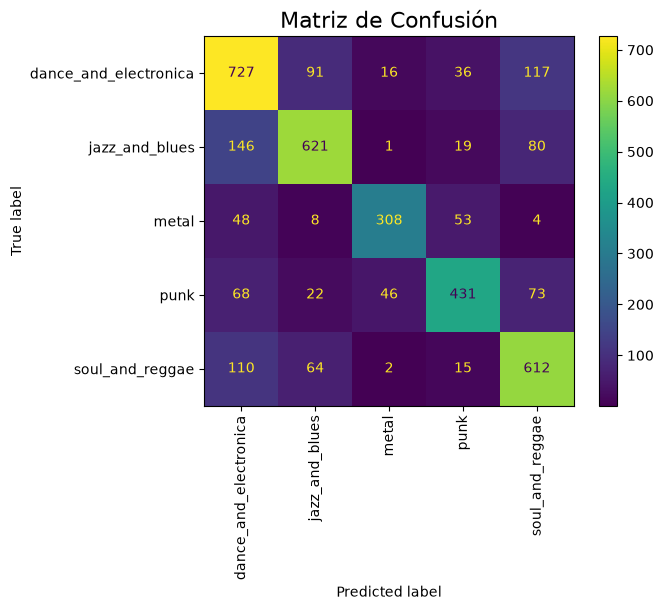

In [26]:
labels = best_model.classes_
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(xticks_rotation=90)
plt.title('Matriz de Confusión', fontsize=16)
plt.show()

Como observamos en la matriz de confusión, la clase de `Dance and Electronica` se suele confundir con más facilidad con las clases de `Soul and Reggae` y `Jazz and Blues`.

La clase `Jazz and Blues` se confunde más frecuentemente con `Dance and Electronica`.

La clase que menos errores comete es la de `Metal` que sus confusiones más frecuentes fueron con las clases `Punk` y `Dance and Electronica`

## Prueba con Neural Networks

In [27]:
import random
import numpy as np
import tensorflow as tf
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adagrad, Adam, RMSprop

random.seed(STATE)
np.random.seed(STATE)
keras.utils.set_random_seed(STATE)

Definimos un EarlyStopping para detener el entrenamiento cuando deje de mejorar la pérdida de la validación

In [28]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

Escalamos los datos para el entrenamiento de neural networks

In [29]:
scaler_nn = StandardScaler()

X_train_scaled = scaler_nn.fit_transform(X_train)
X_test_scaled = scaler_nn.transform(X_test)

n_input = X_train_scaled.shape[1]

X_train_scaled.shape

(14870, 30)

Neural networks no maneja datos categóricos, por lo que codifican estas labels tanto de entrenamiento como de test

In [30]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

n_output = len(label_encoder.classes_)

labels_nn = label_encoder.classes_

dict(enumerate(labels_nn))

{0: 'dance_and_electronica',
 1: 'jazz_and_blues',
 2: 'metal',
 3: 'punk',
 4: 'soul_and_reggae'}

Definimos una función que nos retornará un modelo de neural network con la cantidad de capas ocultas que le digamos y al cual le podemos proveer un optimizador. La idea con esto es probar distintas combinaciones de capas y optimizadores

In [31]:
def get_nn_model(hidden_layers: list, optimizer):
    model = Sequential([
        Input(shape=(n_input,))
    ])

    for l in hidden_layers:
        model.add(
            Dense(l, activation='relu')
        )

    model.add(
        Dense(n_output, activation='softmax')
    )

    model.compile(
        optimizer=optimizer,
        metrics=['accuracy'],
        loss='sparse_categorical_crossentropy'
    )

    return model

Estas funciones nos ayudarán a entender de manera visual cómo se están desempeñando cada uno de los modelos que vamos a entrenar.

In [57]:
def plot_curves(model, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].plot(model.history['loss'])
    ax[0].title.set_text(f'Curva de error del modelo {title}')
    ax[0].set_ylabel('Error')
    ax[0].set_xlabel('Epoca')

    ax[1].plot(model.history['accuracy'])
    ax[1].title.set_text(f'Curva del accuracy del modelo {title}')
    ax[1].set_ylabel('Accuracy')
    ax[1].set_xlabel('Epoca')

    plt.tight_layout()
    plt.show()

def plot_cm(prediction):
    y_pred_fix = np.argmax(prediction, axis=1)

    cm = confusion_matrix(y_test_encoded, y_pred_fix)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_nn)
    disp.plot(xticks_rotation=90)
    plt.title('Matriz de Confusión', fontsize=16)
    plt.show()

Para este proyecto vamos a probar los optimizadores que vimos durante el curso: Adam, Adagrad y RMS prop

### Adam

Primer modelo con dos capas ocultas, una de 32 neuronas y otra de 16, realizando un embudo con un número de neuronas en potencias de 2. Se seleccionan 2 capas por evitar un posible sobre ajuste, aunque probaremos varias combinaciones

In [ ]:
opt_adam_2 = Adam()
model_adam_2 = get_nn_model(
    (32, 16),
    opt_adam_2
)

hist_adam = model_adam_2.fit(X_train_scaled, y_train_encoded, epochs=200, callbacks=[early_stopping])

Epoch 1/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - accuracy: 0.5447 - loss: 1.1330
Epoch 2/200
185/465 ━━━━━━━━━━━━━━━━━━━━ 0s 819us/step - accuracy: 0.6461 - loss: 0.9495

c:\Users\arley\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:100: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step - accuracy: 0.6580 - loss: 0.9192
Epoch 3/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 884us/step - accuracy: 0.6776 - loss: 0.8712
Epoch 4/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.6843 - loss: 0.8448
Epoch 5/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.6916 - loss: 0.8268
Epoch 6/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.6968 - loss: 0.8133
Epoch 7/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 825us/step - accuracy: 0.7008 - loss: 0.8023
Epoch 8/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7034 - loss: 0.7931
Epoch 9/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 811us/step - accuracy: 0.7069 - loss: 0.7853
Epoch 10/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 816us/step - accuracy: 0.7085 - loss: 0.7785
Epoch 11/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - accuracy: 0.7107 - loss: 0.7725
Epoch 12/200
465/465 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - accuracy: 0.7141 - loss: 0.7669
Epoch 13/200
465/465 ━━━━━━━━━

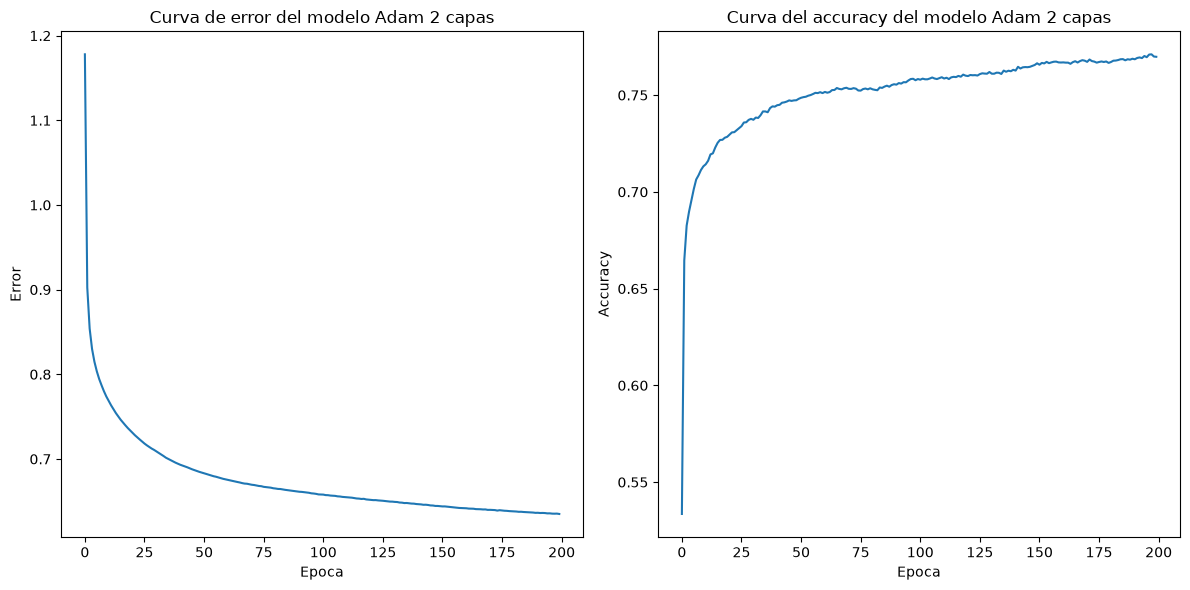

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step


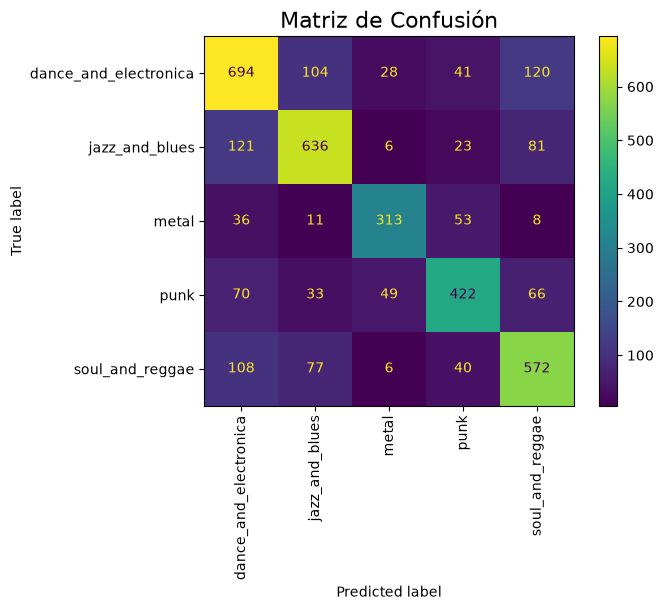

In [58]:
plot_curves(hist_adam, 'Adam 2 capas')
y_pred = model_adam_2.predict(X_test_scaled)
plot_cm(y_pred)

He probado el entrenamiento con diferentes optimizadores y capas ocultas. Las combinaciones utilizadas son las siguientes, para optimizadores:

- Adam
- Adagrad
- RMS prop

y las combinaciones de capas utilizadas fueron:

- 1 capa de 32 neuronas
- 2 capas de 32 y 16 neuronas
- 3 capas de 32, 16 y 8 neuronas

| Adam con 1 capa de 32 neuronas | Adam con 3 capas de 32, 16 y 8 neuronas |
| -- | -- |
|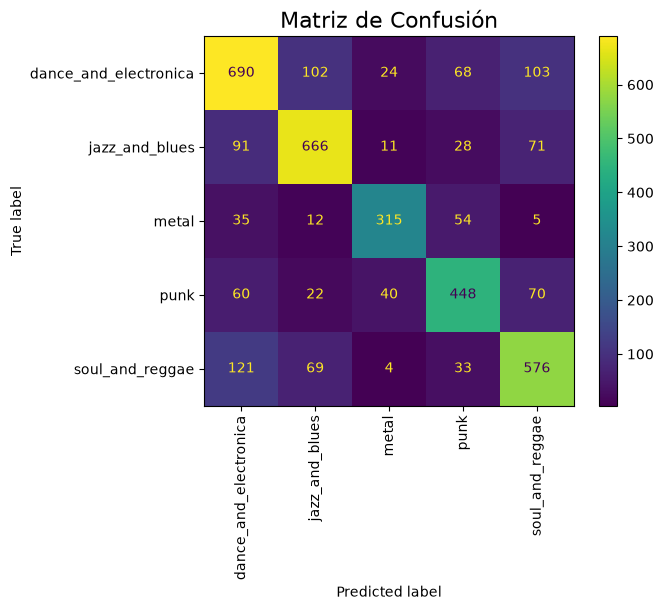 | 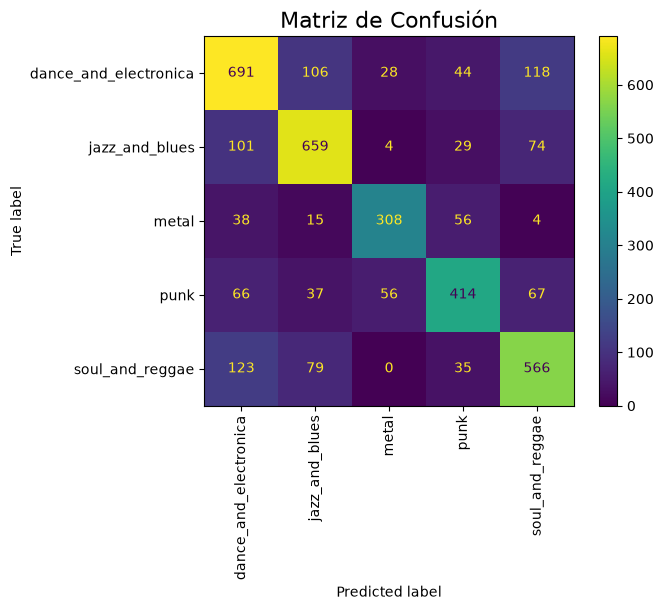 |
| Adagrad con 1 capa de 32 neuronas | Adagrad con 2 capas de 32 y 16 neuronas |
| 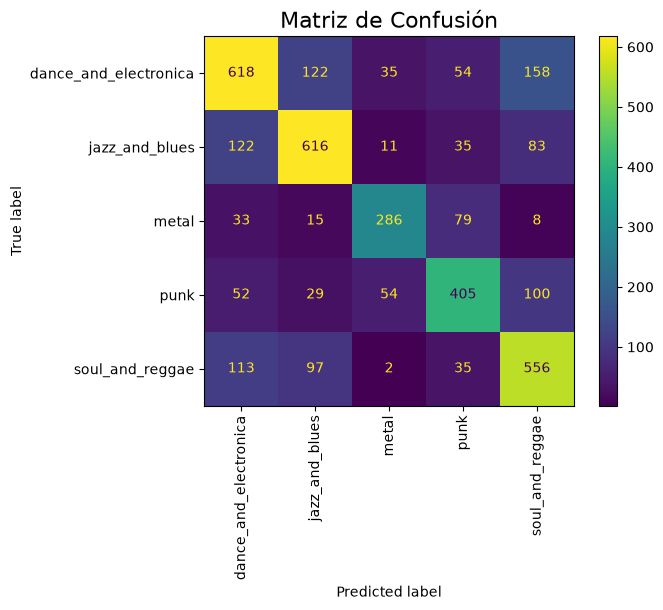 | 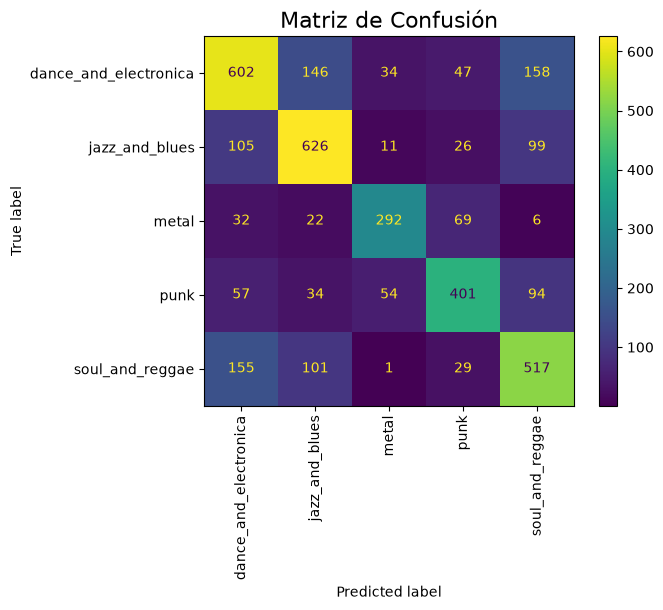 |
| Adagrad con 3 capas de 32, 16 y 8 neuronas | RMS prop con 1 capa de 32 neuronas |
| 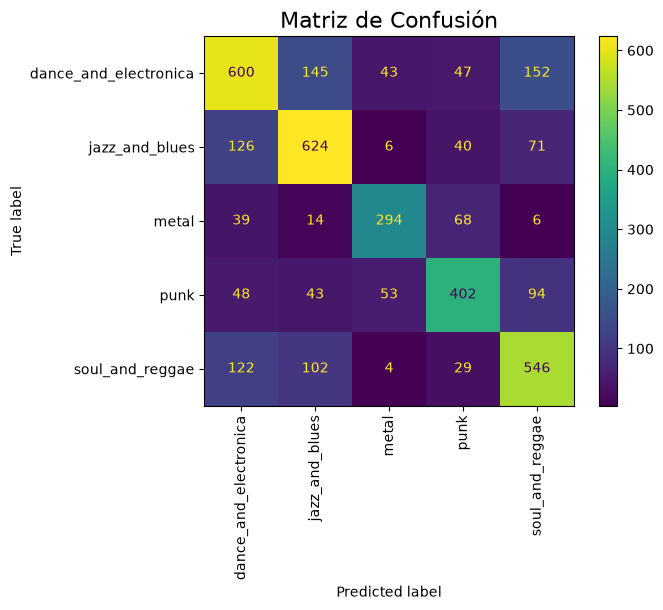 | 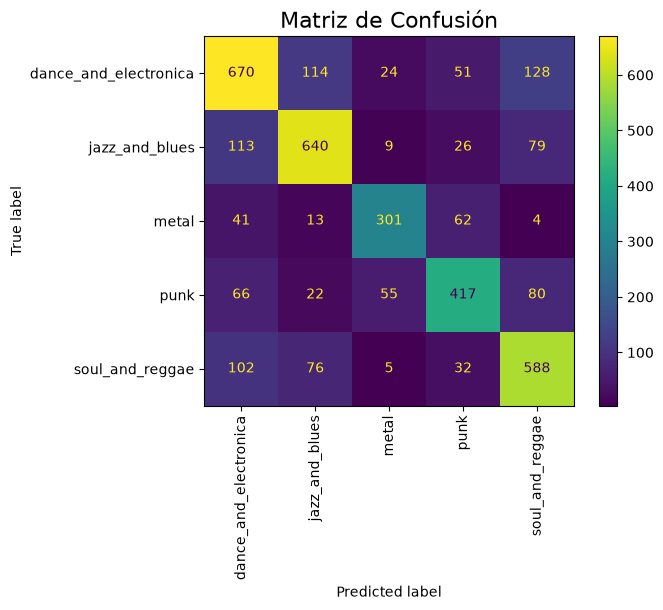 |
| RMS prop con 2 capas de 32 y 16 neuronas | RMS prop con 3 capas de 32, 16 y 8 neuronas |
| 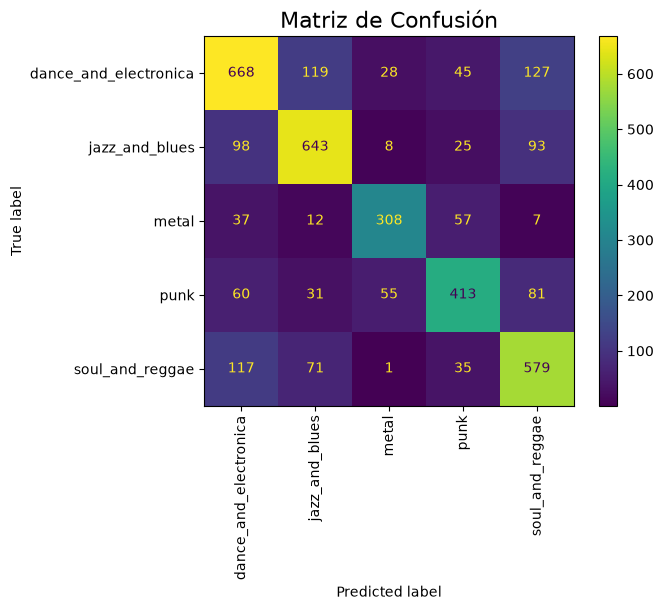 | 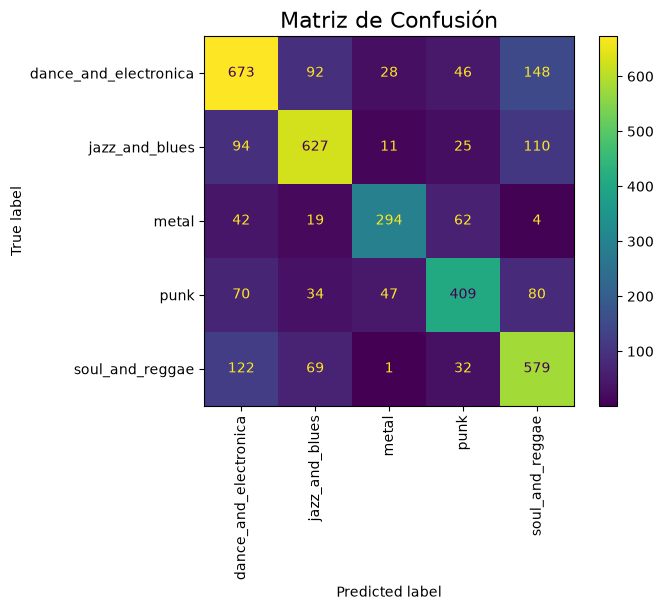 |

Este experimento adicional nos muestra que la red que mejor se desempeñó fue la de Adam con 1 capa oculta de 32 neuronas. Si comparamos todas las matrices de confusión podemos ver que esta fue en general la que menos falsos positivos tuvo en todas las clases.

En general el desempeño fue cercano al obtenido por SVC, pero en realidad esto significa que la red neuronal no demuestra una mejora clara respecto a SVC, además que la red neuronal es de mayor complejidad y supone un mayor costo de entrenamiento, por lo que SVC sigue siendo la opción preferida.